In [31]:
import numpy as np
import pandas as pd

# Task 0
Read the dataset from csv file & perform data cleaning - remove all rows, which contains `?` in some columns.
Also check for data correctness (salary & salary $K).

In [108]:
df = pd.read_csv("adult.csv")
df = df[~df.apply(lambda row: row.astype(str).str.contains('\?').any(), axis=1)]
missing_salary = df['salary'].isnull().sum()
missing_salary_k = df['salary K$'].isnull().sum()
print(f"Missing values in Salary: {missing_salary}")
print(f"Missing values in Salary K$: {missing_salary_k}")

print("\nData types:")
print(df[['salary', 'salary K$']].dtypes)

invalid_salary = df[df['salary'] < 0]
invalid_salary_k = df[df['salary K$'] < 0]
print("\nInvalid Salary values:")
print(invalid_salary)
print("\nInvalid Salary K$ values:")
print(invalid_salary_k)
df['Calculated K$'] = df['salary'] / 1000
inconsistent_entries = df[df['salary K$'] != df['Calculated K$']]
print("\nInconsistent entries between Salary and Salary $K:")
print(inconsistent_entries)
df

<>:2: SyntaxWarning: invalid escape sequence '\?'
<>:2: SyntaxWarning: invalid escape sequence '\?'
C:\Users\toys4\AppData\Local\Temp\ipykernel_23896\4103942872.py:2: SyntaxWarning: invalid escape sequence '\?'
  df = df[~df.apply(lambda row: row.astype(str).str.contains('\?').any(), axis=1)]


Missing values in Salary: 0
Missing values in Salary K$: 0

Data types:
salary       object
salary K$     int64
dtype: object


TypeError: '<' not supported between instances of 'str' and 'int'

# Task 1
Print the count of men and women in the dataset.

In [63]:
female_count = len(df[df["sex"]=="Female"])
print(f"count of female {female_count}")
men_count = len(df[df["sex"]=="Male"])
print(f"count of male {men_count}")

count of female 10771
count of male 21790


# Task 2
Find the average age of men in dataset

In [66]:
men_df = df[df['sex'] == 'Male']

average_age_men = men_df['age'].mean()
print(f"The average age of men in the dataset is: {average_age_men}")

The average age of men in the dataset is: 39.43354749885268


# Task 3
Get the percentage of people from Poland (native-country)

In [76]:
people_pol = df[df["native-country"]=="Poland"]
other_nations = len(df)
percentage = len(people_pol) / other_nations * 100
print(f"percentage of people from Poland: {percentage}")

percentage of people from Poland: 0.18426952489174164


# Task 4
Get the mean and standard deviation of the age for people who earn > 50K per year. After this, get it for those who earn <= 50K.

In [81]:
high_salary = df[df['salary'] == '>50K']
low_salary = df[df['salary'] == '<=50K']
mean_high = high_salary['age'].mean()
std_high = high_salary['age'].std()
mean_low = low_salary['age'].mean()
std_low = low_salary['age'].std()

print(f"mean and standard deviation of people with high salary {mean_high}, {std_high}")
print(f"mean and standard deviation of people with low salary {mean_low}, {std_low}")

mean and standard deviation of people with high salary 44.24984058155847, 10.519027719851826
mean and standard deviation of people with low salary 36.78373786407767, 14.02008849082488


# Task 5
Check, if there are some people without higher education (education: Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters, Doctorate), but with > 50K salary

In [85]:
higher_education = ['Bachelors', 'Prof-school', 'Assoc-acdm', 'Assoc-voc', 'Masters', 'Doctorate']
filtered_df = df[(~df['education'].isin(higher_education)) & (df['salary'] == '>50K')]
filtered_df

,Unnamed: 0,age,workclass,education,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,salary,salary K$
7,7,52,Self-emp-not-inc,HS-grad,Married-civ-spouse,Exec-managerial,Husband,White,Male,45,United-States,>50K,307
10,10,37,Private,Some-college,Married-civ-spouse,Exec-managerial,Husband,Black,Male,80,United-States,>50K,116
27,27,54,?,Some-college,Married-civ-spouse,?,Husband,Asian-Pac-Islander,Male,60,South,>50K,275
38,38,31,Private,Some-college,Married-civ-spouse,Sales,Husband,White,Male,38,?,>50K,166
55,55,43,Private,Some-college,Married-civ-spouse,Tech-support,Husband,White,Male,40,United-States,>50K,341
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32510,32510,39,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,45,?,>50K,212
32518,32518,57,Local-gov,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,40,United-States,>50K,116
32519,32519,46,Private,Some-college,Married-civ-spouse,Exec-managerial,Husband,White,Male,48,United-States,>50K,239
32557,32557,40,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,40,United-States,>50K,173


# Task 6
Get the statistics of age for each type of education. Use `groupby` and `describe` for this.

In [86]:
age_stats_by_education = df.groupby('education')['age'].describe()
print(age_stats_by_education)

                count       mean        std   min    25%   50%   75%   max
education                                                                 
10th            933.0  37.429796  16.720713  17.0  22.00  34.0  52.0  90.0
11th           1175.0  32.355745  15.545485  17.0  18.00  28.0  43.0  90.0
12th            433.0  32.000000  14.334625  17.0  19.00  28.0  41.0  79.0
1st-4th         168.0  46.142857  15.615625  19.0  33.00  46.0  57.0  90.0
5th-6th         333.0  42.885886  15.557285  17.0  29.00  42.0  54.0  84.0
7th-8th         646.0  48.445820  16.092350  17.0  34.25  50.0  61.0  90.0
9th             514.0  41.060311  15.946862  17.0  28.00  39.0  54.0  90.0
Assoc-acdm     1067.0  37.381443  11.095177  19.0  29.00  36.0  44.0  90.0
Assoc-voc      1382.0  38.553546  11.631300  19.0  30.00  37.0  46.0  84.0
Bachelors      5355.0  38.904949  11.912210  19.0  29.00  37.0  46.0  90.0
Doctorate       413.0  47.702179  11.784716  24.0  39.00  47.0  55.0  80.0
HS-grad       10501.0  38

# Task 7
Compare the married and non-married men salaries. Who earns more? (>50K or <=50K)
Married men are those, whom `marital-status` starts with "Married". Others are not.

In [94]:
men_df = df[df['sex'] == 'Male']
married_men = men_df[men_df['marital-status'].str.startswith('Married')]

non_married_men = men_df[~men_df['marital-status'].str.startswith('Married')]
married_high_income = len(married_men[married_men['salary'] == '>50K'])
married_low_income = len(married_men[married_men['salary'] == '<=50K'])

non_married_high_income = len(non_married_men[non_married_men['salary'] == '>50K'])
non_married_low_income = len(non_married_men[non_married_men['salary'] == '<=50K'])

total_married = len(married_men)
total_non_married = len(non_married_men)

if total_married > 0:
    married_high_percent = (married_high_income / total_married) * 100
    married_low_percent = (married_low_income / total_married) * 100
else:
    married_high_percent = 0
    married_low_percent = 0

if total_non_married > 0:
    non_married_high_percent = (non_married_high_income / total_non_married) * 100
    non_married_low_percent = (non_married_low_income / total_non_married) * 100
else:
    non_married_high_percent = 0
    non_married_low_percent = 0
print("Married Men:")
print(f"  >50K: {married_high_percent:.2f}% ({married_high_income} out of {total_married})")
print(f"  <=50K: {married_low_percent:.2f}% ({married_low_income} out of {total_married})")

print("\nNon-Married Men:")
print(f"  >50K: {non_married_high_percent:.2f}% ({non_married_high_income} out of {total_non_married})")
print(f"  <=50K: {non_married_low_percent:.2f}% ({non_married_low_income} out of {total_non_married})")

Married Men:
  >50K: 44.05% (5965 out of 13541)
  <=50K: 55.95% (7576 out of 13541)

Non-Married Men:
  >50K: 8.45% (697 out of 8249)
  <=50K: 91.55% (7552 out of 8249)


# Task 8
Get the max hours per week some person works. How many people works the same amount of hours per week?

In [97]:
max_hours = df['hours-per-week'].max()
num_people_max_hours = len(df[df['hours-per-week'] == max_hours])
print(f"The maximum hours per week worked by someone is: {max_hours}")
print(f"Number of people working {max_hours} hours per week: {num_people_max_hours}")


The maximum hours per week worked by someone is: 99
Number of people working 99 hours per week: 85


# Task 9
Analyze the correlation between data in dataset. Understand connected fields in it and print highlight thier connection.

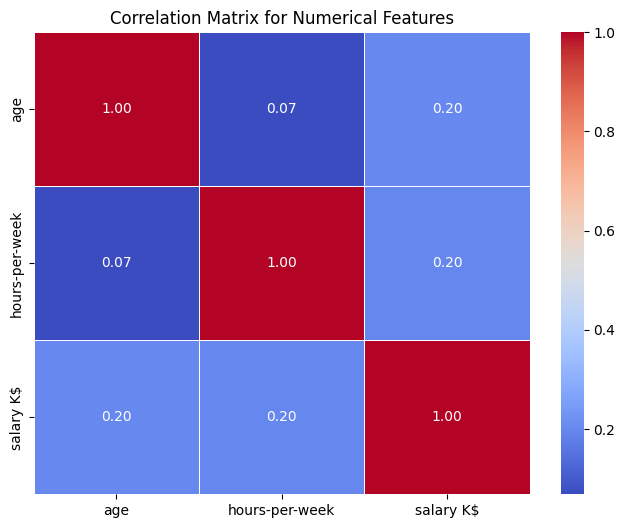

education
Prof-school     154.435764
Doctorate       154.125908
Masters         123.163088
Bachelors       101.882353
Assoc-voc        76.188133
Assoc-acdm       74.993440
Some-college     64.214785
HS-grad          59.573469
12th             42.914550
10th             42.839228
Name: salary K$, dtype: float64

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix = df[['age', 'hours-per-week', 'salary K$']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix for Numerical Features")
plt.show()

category_corr = df.groupby('education')['salary K$'].mean().sort_values(ascending=False)
category_corr.head(10)

